# Summary on using VAEs to compress gLV data with different network sparsity

Author: Zhengqing Zhou
Updated: 2026/06/10

In this notebook, we recall the models trained on each dataset from bounded gLV model parameterized with different network sparsity,  and quantify the essential dimensionality for reconstructing n_target population dynamics

> ### Reproducibility &amp; data
>
> This notebook reproduces the interaction-network FUV / Eᴄ figures from the in-repo `saved_data/` caches (plus a bgLV reference from `../VAE_gLV_simulation/`). Reloading models / `saved_sims/` needs Zenodo.
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import trange
from torch.nn import functional as F
from torch import nn

from sklearn.metrics import r2_score

from VAE_model import *

# Configure GPU if available
if torch.cuda.is_available():

    device = "cuda:0"
else:
    device = "cpu"

display(device)

## Visualize the target dynamics

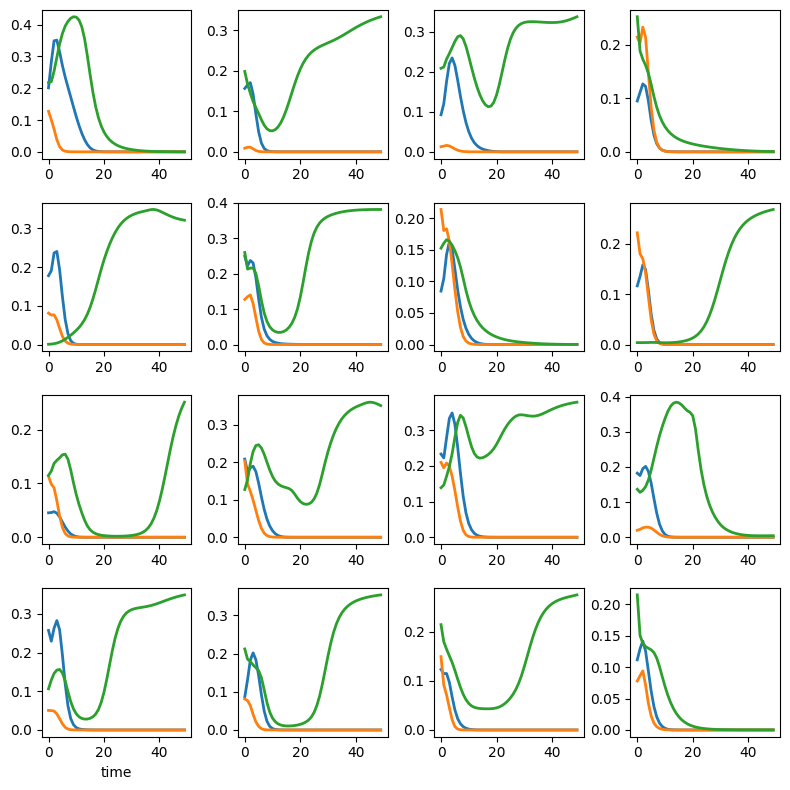

In [2]:
n_target = 3
model_index = 8
X_test = np.load(f"./saved_sims/I{model_index}/bgLV_T{n_target}_random_test.npy")
fig,axes=plt.subplots(4,4,figsize=(8,8))
axes=axes.flat
for i,ax in enumerate(axes):
    y_target = X_test[i]
    for j in range(n_target):
        ax.plot(y_target[j,:],lw=2)
ax=axes[12]
ax.set_xlabel("time")
fig.tight_layout()
        

# Visualize the reconstruction of a given trained model

> ⚠️ **Requires Zenodo artifacts.** The cell(s) below reload trained models (`torch.load` / `load_state_dict`) or heavy arrays. To reproduce the published figure *without* a download, skip to the plotting cells that read the in-repo `.txt` caches. Restore artifacts first with `zenodo/zenodo_download.sh` (see `DATA.md`).

R2: 1.00, mse: 3.04e-04


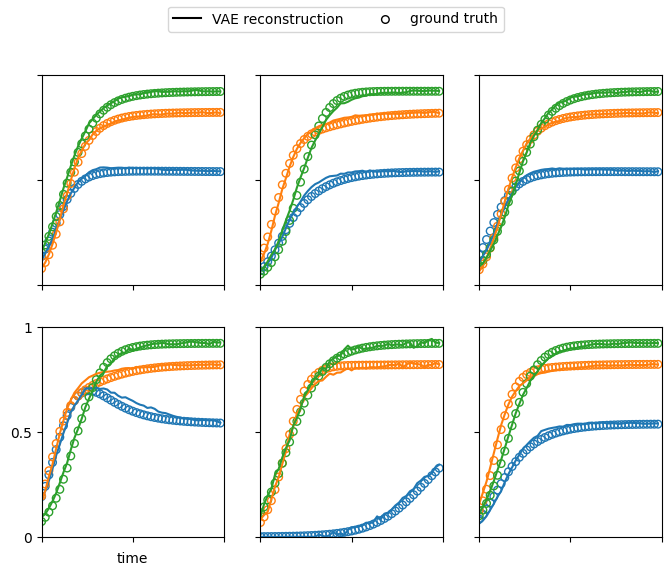

In [4]:
model_index=4
n_target=3
trial=1
x=np.arange(0,50,1)
n_embedding = 3

X_train, X_test = get_data(n_target, model_index)

batch=torch.Tensor(X_train).float()
n_show=6
tp_show=np.arange(0,50,5)
fig,axes=plt.subplots(2,3,figsize=(8,6))
axes=axes.flat

model = VAE(n_target,n_embedding)
model.to("cuda:0");
model.load_state_dict(
    torch.load(
        f"./vae_models/I{model_index}/network_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
)
model.eval()

loss=0
with torch.no_grad():
    pred, code, mu, log_var = model(batch.to(device))
    pred=pred.cpu()
    loss=F.mse_loss(batch,pred).item()
r2 = r2_score(batch.flatten(),pred.flatten())
print(f"R2: {r2:.2f}, mse: {loss:.2e}")
np.random.seed(42)
idx_show = np.random.choice(np.arange(batch.shape[0]),n_show,replace=False)
for i,ii in enumerate(idx_show):
    ax=axes[i]
    data=batch[ii]
    rec=pred[ii]
    for k in range(n_target):
        l=ax.plot(x,rec[k,:],linewidth=1.5)
        ax.scatter(x,data[k,:],s=30,edgecolor=l[-1].get_color(),facecolor="None")
        ax.set_xlim([0,50])
        ax.set_xticks([0,25,50])
        ax.set_xticklabels([])
        ax.set_yticks([0,0.5,1])
        ax.set_yticklabels([])
    ax.set_ylim([0,1])
ax=axes[3]
ax.set_xticklabels([])
ax.set_xlabel("time")
ax.set_yticklabels([0,0.5,1])
ax.plot([],[],c="k",linewidth=1.5,label="VAE reconstruction")
ax.scatter([],[],s=30,edgecolor="k",facecolor="None",label="ground truth")
fig.legend(loc="upper center",ncol=2)

# Effective dimension of observable dynamics in stochastic logistic model

We define a function `get_error` which will return the MSE loss of the reconstruction of a `n_target` populations using an `n_embedding` dimensional VAE model. By iterating through all the parameters, we can then determine the essential dimensionality for the reconstruction of a given size target population dynamics.


In [5]:
def get_error(model,batch,):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_,mu,log_var = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch,reconstruction)
        r2 = r2_score(batch.flatten(), reconstruction.flatten())
        kld = (-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()))
    return mse,kld,r2

# bounded gLV model with different sparsity

In [ ]:
NT=np.arange(2,11,1)
N_EBD = [1, 2, 3, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50]

for model_index in range(2,9,1):
    for i,n_target in enumerate(NT):
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_target, model_index)
        batch_train = torch.Tensor(X_train).float()
        batch_test = torch.Tensor(X_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = VAE(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./vae_models/I{model_index}/network_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True)
                )
                mse_train,kld,r2_train=get_error(model,batch_train)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,kld,r2_test=get_error(model,batch_test)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_train.txt", data_train)
        np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt", data_test)
        print(f"model {model_index}; target {n_target} finished")

Now fit the FUV-embedding relationship to an exponential threshold function

In [19]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

def fit_Ec_for_model(
    model_index,
    p0=(None, 1, 0.1),
    NT=np.arange(2, 11, 1),
    n_trial=5,
    save=True,
    plot=True,
    verbose=True
):
    """
    Fit Ec for one model index.

    Parameters
    ----------
    model_index : int
        Model index, e.g. 1, 2, ..., 10.

    p0 : tuple, dict, or callable
        Initial guess for curve_fit.

        Examples:
        p0 = (None, 1, 0.1)
            uses (n_target, 1, 0.1)

        p0 = (5, 1, 0.1)
            uses same p0 for all n_target

        p0 = {2: (2, 1, 0.1), 3: (3, 1, 0.1), ...}
            uses n_target-specific p0

        p0 = lambda n_target: (n_target, 1, 0.1)
            callable version
    """

    if plot:
        fig, axes = plt.subplots(2, 5, figsize=(10, 4))
        axes = axes.flat
    else:
        fig, axes = None, [None] * len(NT)

    Ec_data = np.zeros((3, len(NT)))
    Ec_data[0, :] = NT

    for i, n_target in enumerate(NT):
        ax = axes[i]

        data = np.loadtxt(
            f"./saved_data/I{model_index}/reconstruction_T{n_target}_test.txt"
        )

        N_EBD = data[0, :]
        FUV = data[1:, :]

        mean_FUV = np.mean(FUV, axis=0)
        std_FUV = np.std(FUV, axis=0, ddof=1)
        se_FUV = std_FUV / np.sqrt(n_trial)

        # Handle p0 flexibly
        if callable(p0):
            this_p0 = p0(n_target)
        elif isinstance(p0, dict):
            this_p0 = p0[n_target]
        else:
            if p0[0] is None:
                this_p0 = (n_target, p0[1], p0[2])
            else:
                this_p0 = p0

        popt, pcov = curve_fit(
            y_exp,
            N_EBD,
            mean_FUV,
            sigma=se_FUV,
            absolute_sigma=True,
            p0=this_p0
        )
        if verbose:
            print(f"model {model_index}, T={n_target}, p0={this_p0}, popt={popt}")

        Ec = popt[0]
        param_errors = np.sqrt(np.diag(pcov))
        Ec_se = param_errors[0]

        Ec_data[1, i] = Ec
        Ec_data[2, i] = Ec_se

        if plot:
            ax.scatter(
                N_EBD,
                mean_FUV,
                fc="white",
                ec="steelblue"
            )

            ax.errorbar(
                N_EBD,
                mean_FUV,
                yerr=se_FUV,
                fmt="none",
                ecolor="k",
                elinewidth=1,
                capsize=3,
                zorder=10
            )

            y_Ec = y_exp(np.array([Ec]), *popt)
            ax.scatter(Ec, y_Ec, c="steelblue")

            xx = np.linspace(1, 50, 1000)
            yy = y_exp(xx, *popt)

            ax.plot(
                xx,
                yy,
                color="steelblue",
                linewidth=1
            )

            ax.text(
                x=0.95,
                y=0.95,
                s="Ec=%1.1f±%1.1f" % (Ec, Ec_se),
                ha="right",
                va="top",
                transform=ax.transAxes
            )

            if i == 5:
                ax.set_xlabel("n$_{embedding}$")
                ax.set_ylabel("FUV%")

            ax.set_xticks(np.arange(0, 50, 10))
            ax.set_ylim([0, np.max(mean_FUV) * 1.2])
            ax.grid(True)

    if plot:
        axes[-1].set_visible(False)
        fig.tight_layout()

    if save:
        np.savetxt(
            f"./saved_data/Ec_network_model{model_index}.txt",
            Ec_data
        )

    return Ec_data, fig

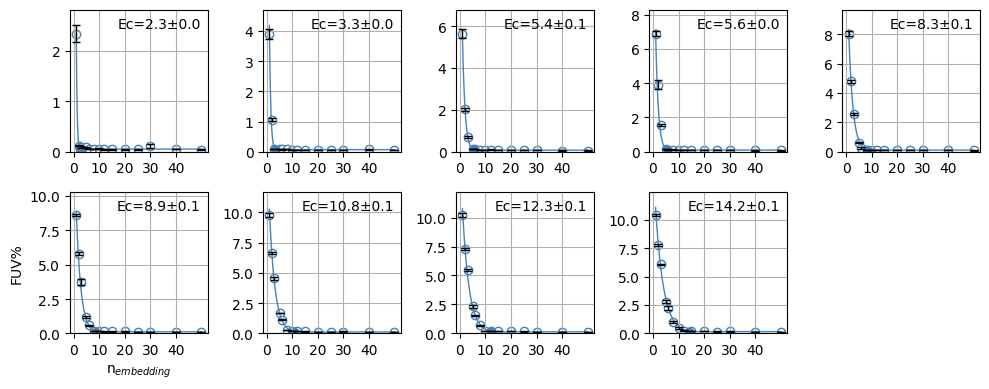

In [20]:
model_index = 2
p0 = lambda n_target: (n_target, 1, 0.1)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

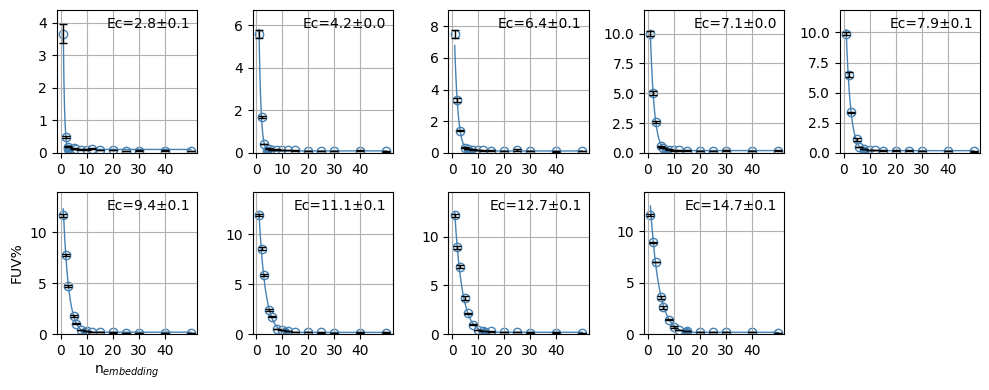

In [21]:
model_index = 3
p0 = lambda n_target: (n_target, 1, 0.1)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

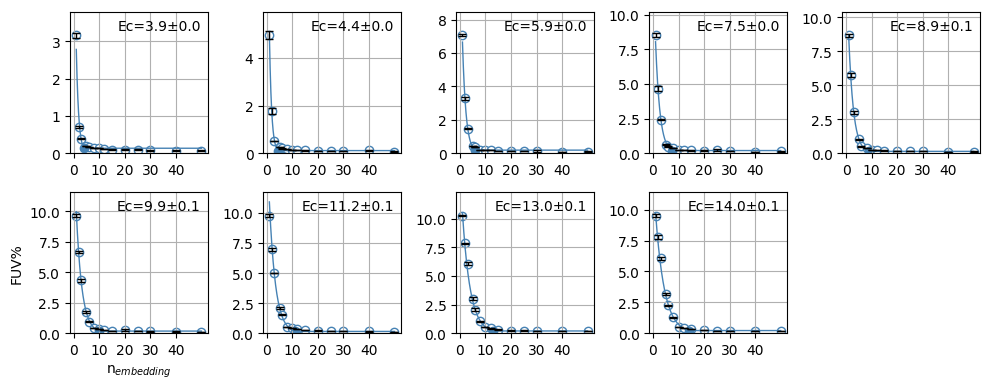

In [22]:
model_index = 4
p0 = lambda n_target: (n_target, 1, 0.1)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

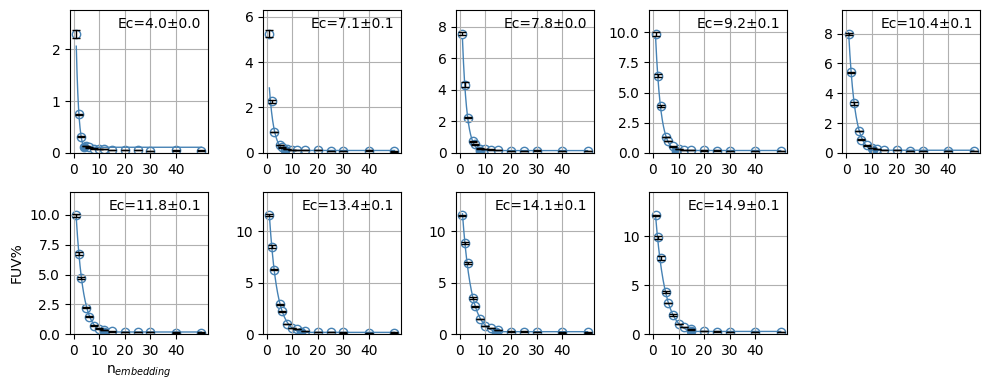

In [23]:
model_index = 5
p0 = lambda n_target: (n_target, 1, 0.1)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

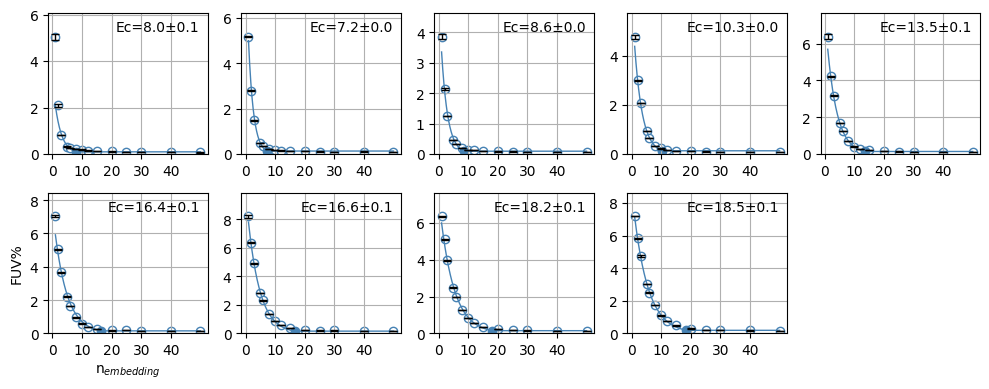

In [24]:
model_index = 6
p0 = lambda n_target: (10+n_target, 0.2, 0.2)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

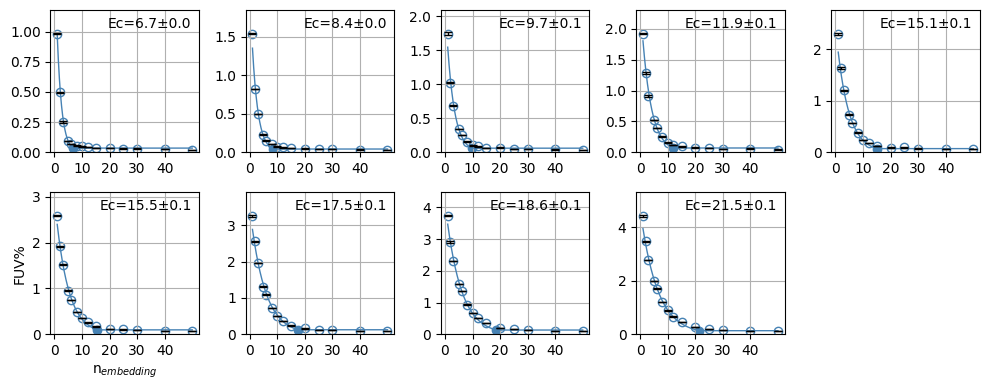

In [25]:
model_index = 7
p0 = lambda n_target: (10+n_target, 0.2, 0.2)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

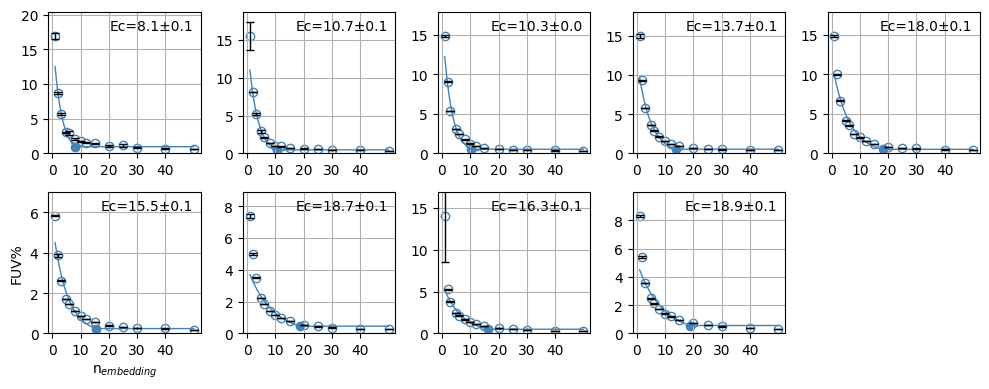

In [26]:
model_index = 8
p0 = lambda n_target: (10+n_target, 0.2, 0.2)
Ec_data, fig = fit_Ec_for_model(
    model_index=model_index,
    p0=p0, verbose=False
)

In [17]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b

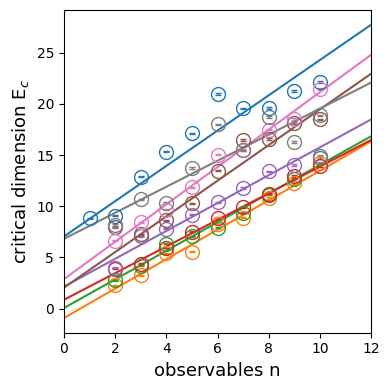

In [ ]:
colors = list(plt.cm.tab10.colors)
fig,ax = plt.subplots(1,1,figsize=(4,4))
for i,model_index in enumerate(range(1,9,1)):
    if model_index == 1:
        data = np.loadtxt(f"../VAE_gLV_simulation/saved_data/bgLV/Ec_bgLV_model1_random.txt")
    else:
        data = np.loadtxt(f"./saved_data/Ec_network_model{model_index}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c=colors[i],mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)

    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)

    R2 = 1 - SS_res / SS_tot

    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c=colors[i])
    ax.set_xlim([0, 12])

ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.tight_layout()

# Effective dimension of single observables 

We trained VAE models to compress single-observable time-series of all members in community 5 (model_index = 5). We now recall these models and deduce the critical dimension of each observable.


In [2]:
def get_error(model,batch,):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_,mu,log_var = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch,reconstruction)
        r2 = r2_score(batch.flatten(), reconstruction.flatten())
        kld = (-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()))
    return mse,kld,r2

In [13]:
from tqdm import tqdm
model_index = 5
N_EBD = [1, 2, 3, 4, 5, 6, 8, 10, 20]
TID = np.arange(0,1,1)

for target_id in tqdm(TID, desc="Processing targets"):
    data_train = np.zeros((4,len(N_EBD)))
    data_train[0,:] = N_EBD
    data_test = np.zeros((4,len(N_EBD)))
    data_test[0,:] = N_EBD
    X_train, X_test = get_indiv_target(target_id, model_index)
    batch_train = torch.Tensor(X_train).float()
    batch_test = torch.Tensor(X_test).float()
    for trial in range(1,3,1):
        for j,n_embedding in enumerate(N_EBD):
            model = VAE(1,n_embedding)
            model.to("cuda:0");
            model.load_state_dict(
                torch.load(
                    f"./vae_models/I{model_index}/"
                    f"indiv_s{target_id}_E{n_embedding}_trial{trial}.pth",weights_only=True)
            )
            mse_train,kld,r2_train=get_error(model,batch_train)
            data_train[trial,j]=(1-r2_train)*100
            mse_test,kld,r2_test=get_error(model,batch_test)
            data_test[trial,j]=(1-r2_test)*100
    save_dir = f"./saved_data/I{model_index}"
    os.makedirs(save_dir, exist_ok=True)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_indiv_s{target_id}_train.txt", data_train)
    np.savetxt(f"./saved_data/I{model_index}/reconstruction_indiv_s{target_id}_test.txt", data_test)

Processing targets: 100%|██████████| 1/1 [00:01<00:00,  1.41s/it]


In [17]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

def fit_Ec_for_indiv_target(
    model_index,
    TID=np.arange(0,100,1),
    n_trial=3,
    save=True,
    plot=True,
):
    """
    Fit Ec for one model index.

    Parameters
    ----------
    model_index : int
        Model index, e.g. 1, 2, ..., 10.

    """

    if plot:
        fig, axes = plt.subplots(10, 10, figsize=(20,20))
        axes = axes.flat
    else:
        fig, axes = None, [None] * len(TID)

    Ec_data = np.zeros((3, len(TID)))
    Ec_data[0, :] = TID

    for i, target_id in enumerate(TID):
        ax = axes[i]

        data = np.loadtxt(
            f"./saved_data/I{model_index}/reconstruction_indiv_s{target_id}_test.txt"
        )

        N_EBD = data[0, :]
        FUV = data[1:, :]

        mean_FUV = np.mean(FUV, axis=0)
        std_FUV = np.std(FUV, axis=0, ddof=1)
        se_FUV = std_FUV / np.sqrt(n_trial)

        p0 = (1,1,0.1)

        popt, pcov = curve_fit(
            y_exp,
            N_EBD,
            mean_FUV,
            sigma=se_FUV,
            absolute_sigma=True,
            p0=p0
        )

        Ec = popt[0]
        param_errors = np.sqrt(np.diag(pcov))
        Ec_se = param_errors[0]

        Ec_data[1, i] = Ec
        Ec_data[2, i] = Ec_se

        if plot:
            ax.scatter(
                N_EBD,
                mean_FUV,
                fc="white",
                ec="steelblue"
            )

            ax.errorbar(
                N_EBD,
                mean_FUV,
                yerr=se_FUV,
                fmt="none",
                ecolor="k",
                elinewidth=1,
                capsize=3,
                zorder=10
            )

            y_Ec = y_exp(np.array([Ec]), *popt)
            ax.scatter(Ec, y_Ec, c="steelblue")

            xx = np.linspace(1, 20, 1000)
            yy = y_exp(xx, *popt)

            ax.plot(
                xx,
                yy,
                color="steelblue",
                linewidth=1
            )

            ax.text(
                x=0.95,
                y=0.95,
                s="Ec=%1.1f±%1.1f" % (Ec, Ec_se),
                ha="right",
                va="top",
                transform=ax.transAxes
            )

            if i == 5:
                ax.set_xlabel("n$_{embedding}$")
                ax.set_ylabel("FUV%")

            ax.set_xticks(np.arange(0, 20, 10))
            ax.set_xlim([0,20])
            ax.set_ylim([0, np.max(mean_FUV) * 1.2])
            ax.grid(True)

    if plot:
        fig.tight_layout()

    if save:
        np.savetxt(
            f"./saved_data/Ec_indiv_model{model_index}.txt",
            Ec_data
        )

    return Ec_data, fig

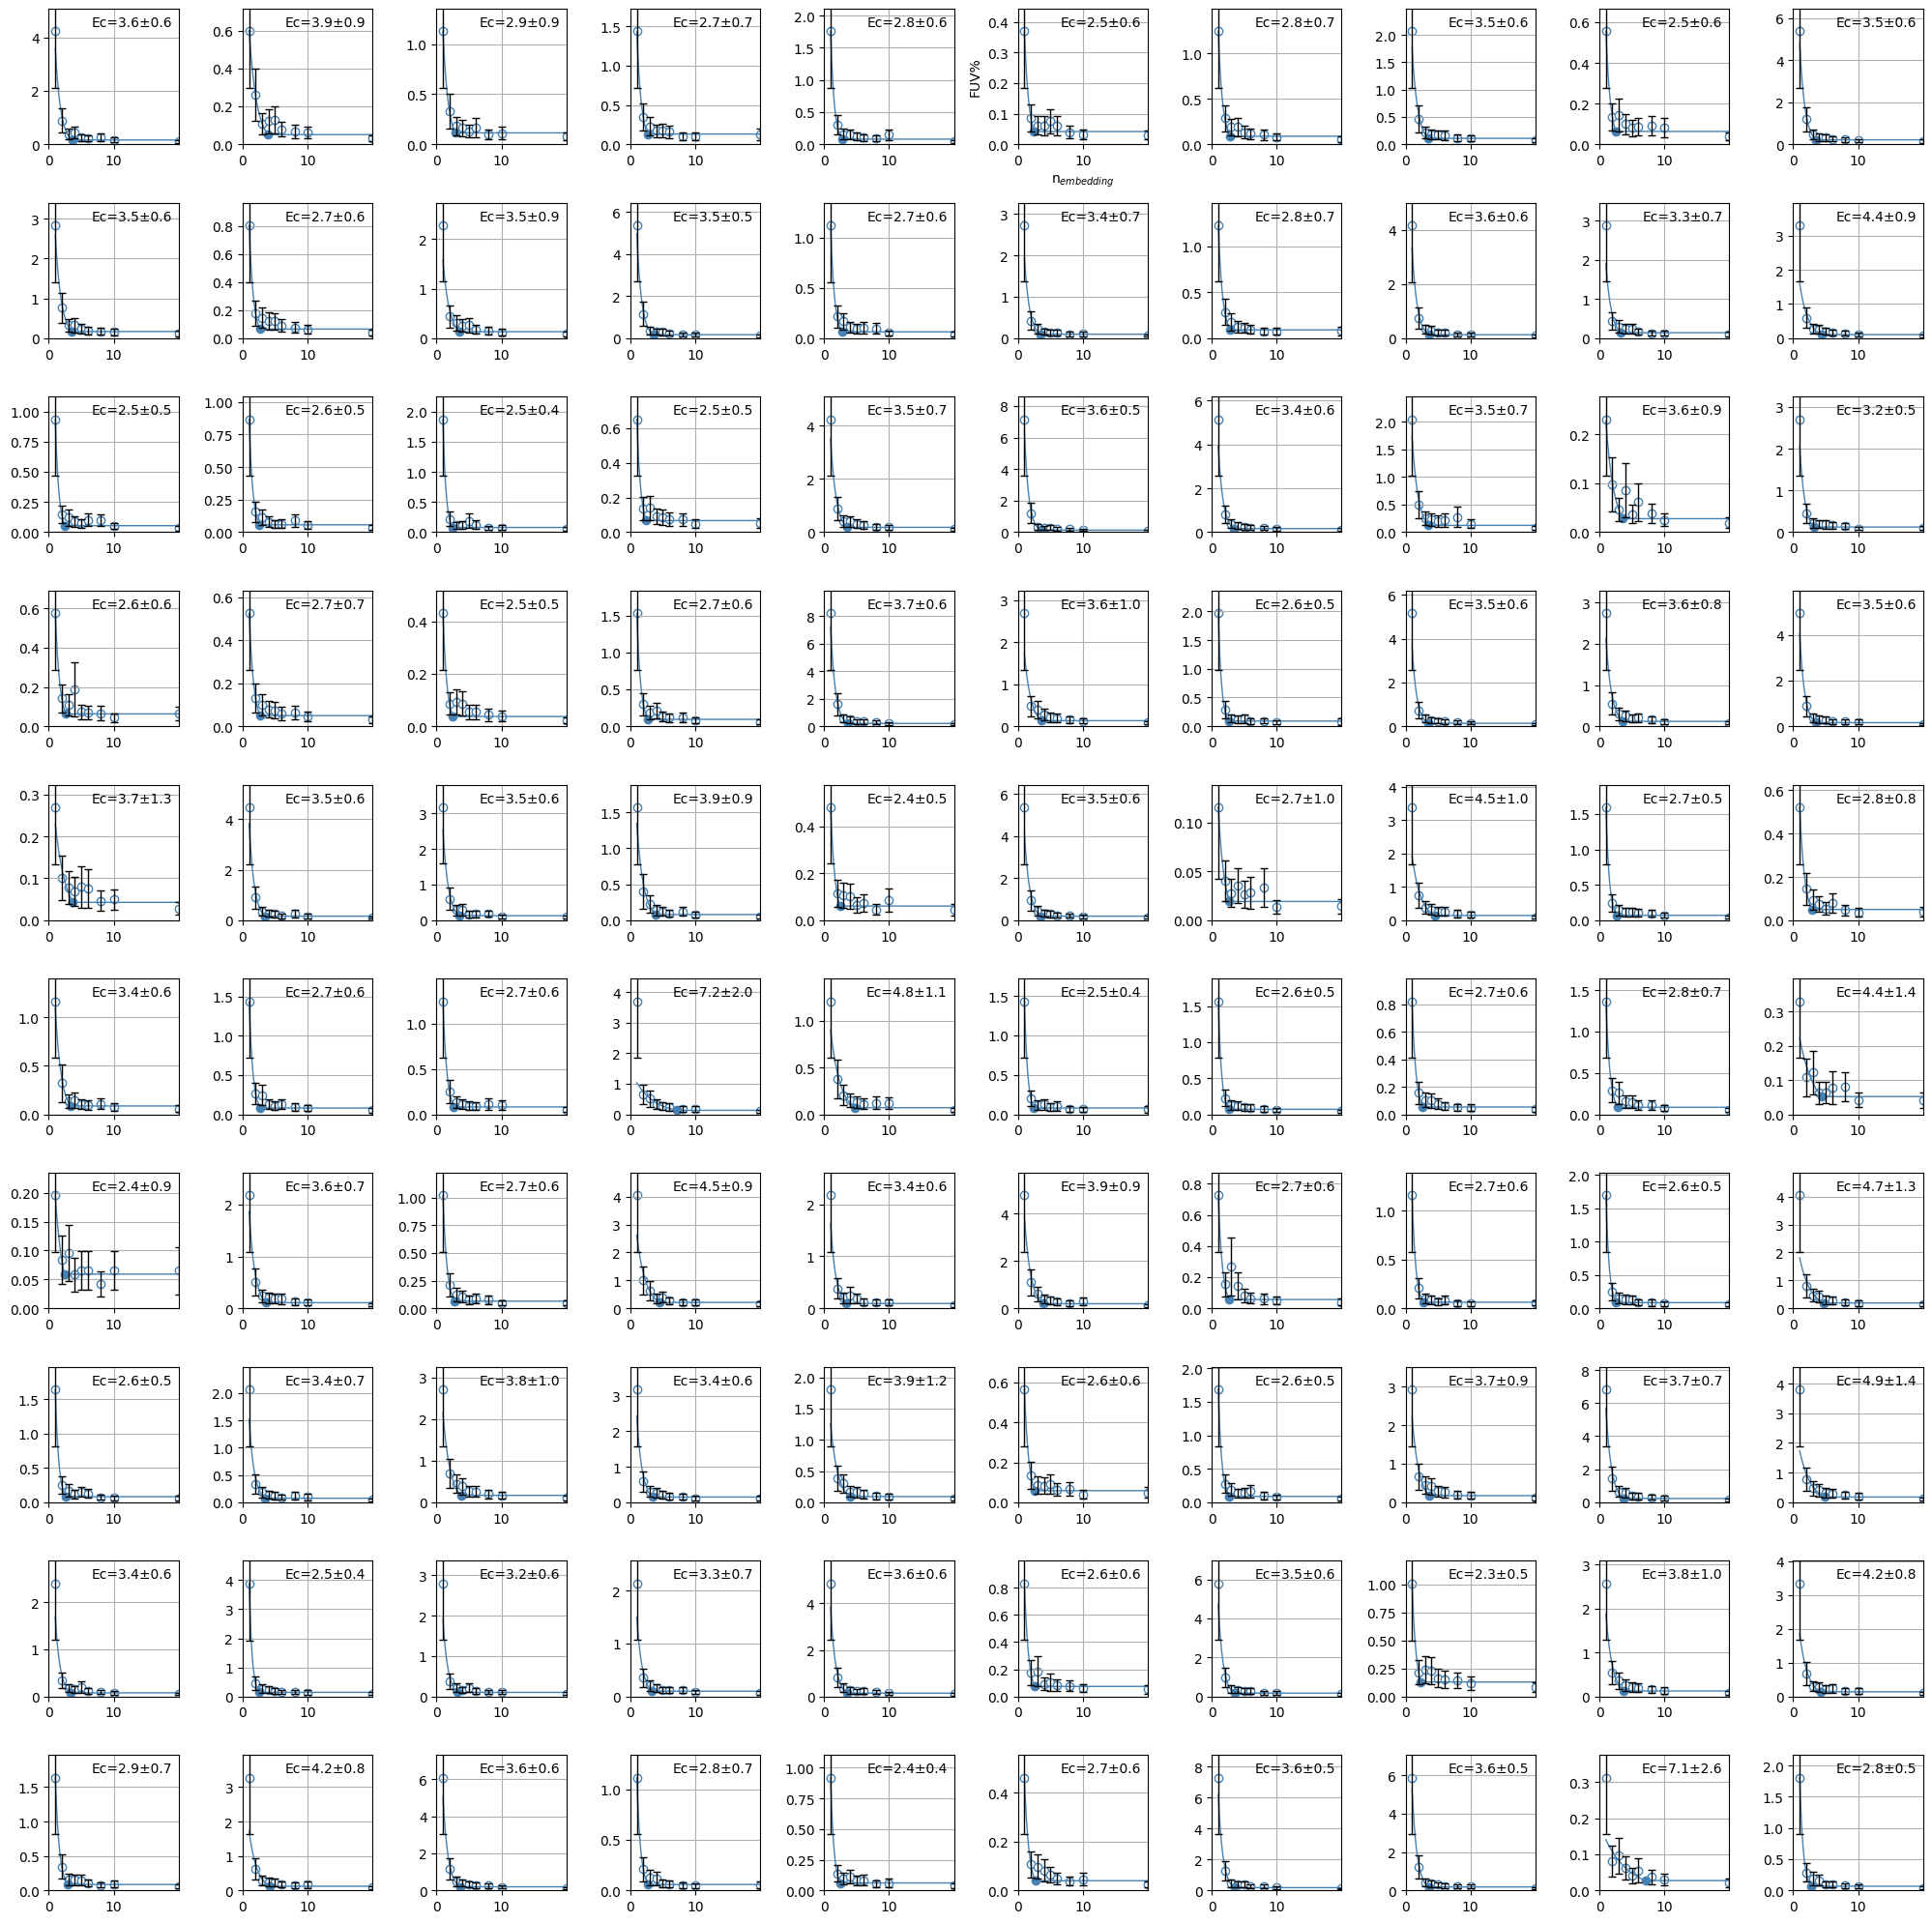

In [18]:
model_index = 5
Ec_data, fig = fit_Ec_for_indiv_target(
    model_index=model_index,
)

logistic model
Slope            : 0.161 ± 0.031 (SE)
Intercept        : 2.264 ± 0.164 (SE)
t-statistic      : 5.12  (dof = 98)
p-value (slope≠0): 1.55e-06
Weighted R²      : 0.331


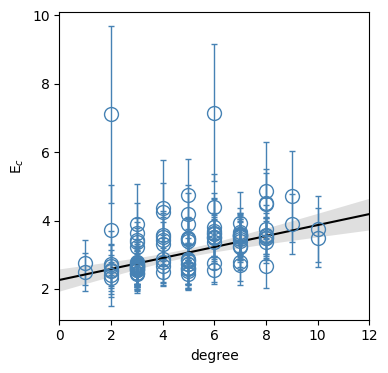

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b
model_index = 5
fig,ax = plt.subplots(1,1,figsize=(4,4))
degree = np.loadtxt(f"./saved_sims/I{model_index}/network_degrees_I{model_index}.txt")
degree = degree[:,1]
Ec_data = np.loadtxt(f"./saved_data/Ec_indiv_model{model_index}.txt")
# Extract x, y, and CI bounds
N_TG = Ec_data[0,:]
Ec = Ec_data[1,:]
Ec_se = Ec_data[2,:]
ax.errorbar(degree,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                elinewidth=1)

# Weighted fit using standard errors
popt, pcov = curve_fit(linear_model, degree, Ec, sigma=Ec_se, absolute_sigma=True)
slope, intercept = popt
slope_se, intercept_se = np.sqrt(np.diag(pcov))

# residuals and total sums of squares
y_pred = linear_model(degree, slope, intercept)
SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)

R2 = 1 - SS_res / SS_tot

# Compute t-statistic and p-value
dof = len(degree) - 2
t_stat = slope / slope_se
p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

# Generate fit line and CI band
x_fit = np.linspace(0, 12, 100)
y_fit = linear_model(x_fit, slope, intercept)

# ----- CI band for fitted mean --------------------------------------------

alpha = 0.05  # 95% CI
t_crit = t.ppf(1 - alpha / 2, df=dof)

# Design matrix for y = a*x + b
X_fit = np.vstack([x_fit, np.ones_like(x_fit)]).T

# Variance of fitted mean at each x:
# Var(y_fit) = X pcov X^T
fit_var = np.sum((X_fit @ pcov) * X_fit, axis=1)
fit_se = np.sqrt(fit_var)

ci_lower = y_fit - t_crit * fit_se
ci_upper = y_fit + t_crit * fit_se

ax.plot(x_fit, y_fit, c="k")
ax.fill_between(x_fit, ci_lower, ci_upper, color="gray", alpha=0.25, linewidth=0)

ax.set_xlim([0, 12])
ax.set_xlabel("degree")
ax.set_ylabel("E$_c$")
# ----- formatted report ---------------------------------------------------
report = (
    f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
    f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
    f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
    f"p-value (slope≠0): {p_value:.3g}\n"
    f"Weighted R²      : {R2:.3f}"
)

print(report)

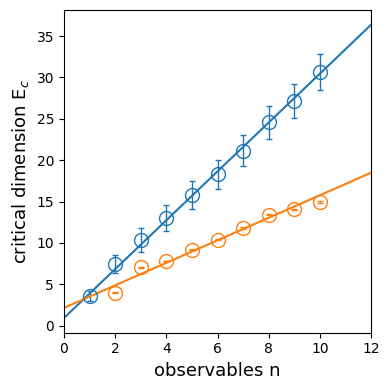

In [26]:
colors = list(plt.cm.tab10.colors)
fig,ax = plt.subplots(1,1,figsize=(4,4))
indiv_Ec = np.loadtxt(f"./saved_data/Ec_indiv_model{model_index}.txt")
cumsum_Ec = np.zeros((3,10))
cumsum_Ec[0,:] = np.arange(1,11,1)
cumsum_Ec[1,:] = np.cumsum(indiv_Ec[1,:10])
cumsum_Ec[2,:] = np.sqrt(np.cumsum(indiv_Ec[2,:10]**2))
grouped_Ec= np.loadtxt(f"./saved_data/Ec_network_model{model_index}.txt")
for i,Ec_data in enumerate([cumsum_Ec,grouped_Ec]):
    # Extract x, y, and CI bounds
    N_TG = Ec_data[0,:]
    Ec = Ec_data[1,:]
    Ec_se = Ec_data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c=colors[i],mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)

    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)

    R2 = 1 - SS_res / SS_tot

    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c=colors[i])
    ax.set_xlim([0, 12])

    ax.set_xlabel("observables n", fontsize=13)
    ax.set_ylabel("critical dimension E$_c$", fontsize=13)
    fig.tight_layout()